# Домашнее задание 3. Анализ данных

Задание выполнил: Фирсов Федор

# Часть I

Каждое задание в этой части оценивается в 0,15 баллов. Всего за выполнение этой части можно получить 2,55 балла.

In [2]:
import pandas as pd
import seaborn as sns
from scipy.stats import norm

In [3]:
DIABETS = 'https://raw.githubusercontent.com/evgpat/datasets/main/pima_indians_diabetes.csv'
BABIES = 'https://raw.githubusercontent.com/evgpat/datasets/main/babies_all.txt'

Будем работать с датасетом Pima Indian Diabetes - это набор данных из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является диагностическое прогнозирование наличия диабета у пациента. Несколько ограничений были наложены на выбор этих экземпляров из большой базы данных. В частности, все пациенты здесь - женщины в возрасте от 21 года, индийского происхождения.

In [4]:
data = pd.read_csv(DIABETS)
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


Описание данных:

- __Pregnancies__ - данная единица отображает количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - данная единица отображает уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - данная единица отображает артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - данная единица отображает обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - данная единица отображает уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - данная единица отображает индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - данная единица отображает риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - данная единица отражает возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - данная единица отражает наличие диабета у субъекта, выражена 0(здоров) или 1(болен). Тип переменной - категориальная, бинарная.

## Задание 1

Как вы видите, в данных много пропусков (NaN). Любым способом посчитайте количество пропусков в каждом из столбцов.

Для тех переменных, в которых есть пропуски, выведите количество пропущенных значений в следующем формате:

**"В переменной {название переменной} {количество} пропущенных значений"**

In [6]:
nan_counts = data.isnull().sum()
for column, count in nan_counts.items():
    if count > 0:
        print(f"В переменной {column} {count} пропущенных значений")

В переменной Glucose 5 пропущенных значений
В переменной BloodPressure 35 пропущенных значений
В переменной SkinThickness 227 пропущенных значений
В переменной Insulin 374 пропущенных значений
В переменной BMI 11 пропущенных значений


## Задание 2

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [9]:
for col in ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'Age']:
    data[col] = data[col].fillna(data[col].median())

for col in ['BMI', 'DiabetesPedigreeFunction']:
    data[col] = data[col].fillna(data[col].mean())

print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Class                       0
dtype: int64


## Задание 3

Выведите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [11]:
import pandas as pd
import numpy as np

def get_stat_table(df):
    stat_table = pd.DataFrame({
        'min': df.min(),
        'max': df.max(),
        'mean': df.mean(),
        'var': df.var(),
        '25%': df.quantile(0.25),
        '50%': df.quantile(0.5),
        '75%': df.quantile(0.75)
    })
    return stat_table

stats = get_stat_table(data)
print(stats)


                             min     max        mean          var        25%  \
Pregnancies                0.000   17.00    3.845052    11.354056    1.00000   
Glucose                   44.000  199.00  121.656250   926.489244   99.75000   
BloodPressure             24.000  122.00   72.386719   146.328741   64.00000   
SkinThickness              7.000   99.00   29.108073    77.285567   25.00000   
Insulin                   14.000  846.00  140.671875  7462.033002  121.50000   
BMI                       18.200   67.10   32.457464    47.267706   27.50000   
DiabetesPedigreeFunction   0.078    2.42    0.471876     0.109779    0.24375   
Age                       21.000   81.00   33.240885   138.303046   24.00000   
Class                      0.000    1.00    0.348958     0.227483    0.00000   

                               50%        75%  
Pregnancies                 3.0000    6.00000  
Glucose                   117.0000  140.25000  
BloodPressure              72.0000   80.00000  
SkinThi

## Задание 4

У скольких женщин строго старше 50 лет обнаружен диабет?

In [12]:
print(data[(data['Age'] > 50) & (data['Class'] == 1)].shape[0])

38


## Задание 5

Найдите трех женщин с наибольшими числом беременностей.

In [14]:
print(data.sort_values(by='Pregnancies', ascending=False).head(3))

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
159           17    163.0           72.0           41.0    114.0  40.9   
88            15    136.0           70.0           32.0    110.0  37.1   
298           14    100.0           78.0           25.0    184.0  36.6   

     DiabetesPedigreeFunction  Age  Class  
159                     0.817   47      1  
88                      0.153   43      1  
298                     0.412   46      1  


## Задание 6

Сколько женщин возраста между 30 и 40 успело родить 3 или более детей?

In [15]:
print(data[(data['Age'] >= 30) & (data['Age'] <= 40) & (data['Pregnancies'] >= 3)].shape[0])

142


## Задание 7

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [19]:
percent = 100 * data[(data['BloodPressure'] >= 80) & (data['BloodPressure'] <= 89)].shape[0] / data.shape[0]
print(f"{percent:.2f}%")

18.88%


## Задание 8

Считается, что BMI >= 30 - это признак ожирения.
У скольких женщин с признаками ожирения кровяное давление выше среднего?

In [20]:
obese = data[data['BMI'] >= 30]
percent = obese[obese['BloodPressure'] >  data['BloodPressure'].mean()].shape[0]
print(f"{percent}")


251


## Задание 9

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет.

In [ ]:
print(data[data['Class'] == 1]['Glucose'].mean())
print(data[data['Class'] == 0]['Glucose'].mean())

142.13059701492537
110.682


In [22]:
print(data[data['Class'] == 1]['BloodPressure'].mean())
print(data[data['Class'] == 0]['BloodPressure'].mean())

75.1231343283582
70.92


In [23]:
print(data[data['Class'] == 1]['Insulin'].mean())
print(data[data['Class'] == 0]['Insulin'].mean())

164.70149253731344
127.792


## Задание 10

Постройте гистограммы для любых двух количественных признаков.

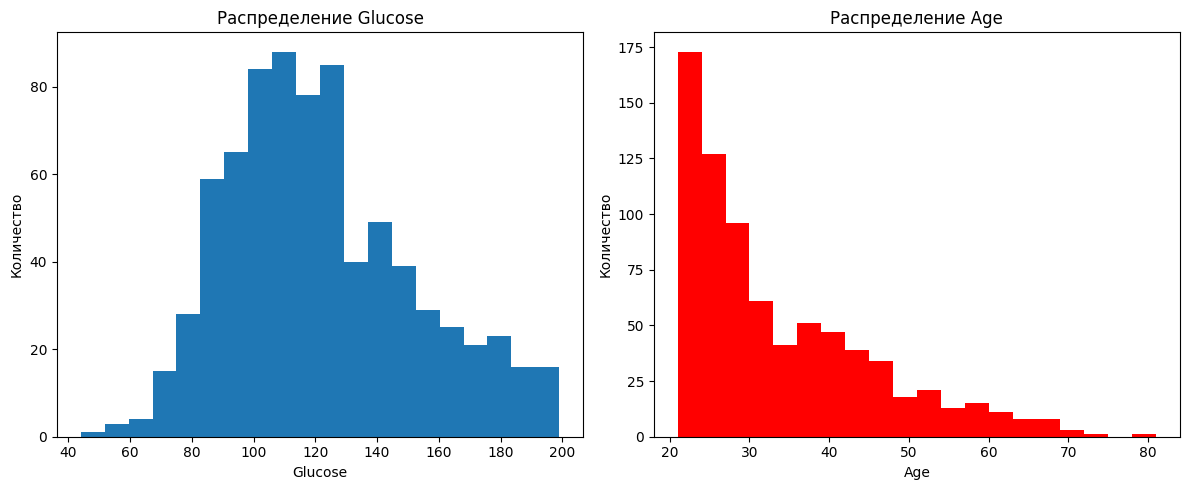

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data['Glucose'], bins=20)
plt.title('Распределение Glucose')
plt.xlabel('Glucose')
plt.ylabel('Количество')

plt.subplot(1,2,2)
plt.hist(data['Age'], bins=20, color='red')
plt.title('Распределение Age')
plt.xlabel('Age')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

## Задание 11

Постройте круговую диаграмму для признака __Class__.

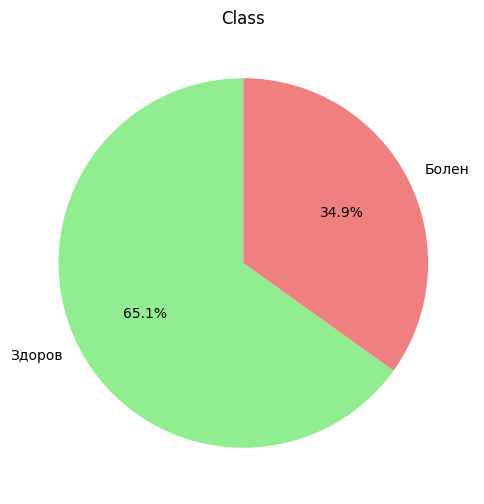

In [35]:
labels = ['Здоров', 'Болен']
sizes = data['Class'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
plt.title('Class')
plt.show()

## Задание 12

Постройте распределение для признака __BMI__ и сравните его с нормальным (напишите вывод в новой markdown-ячейке под графиками)

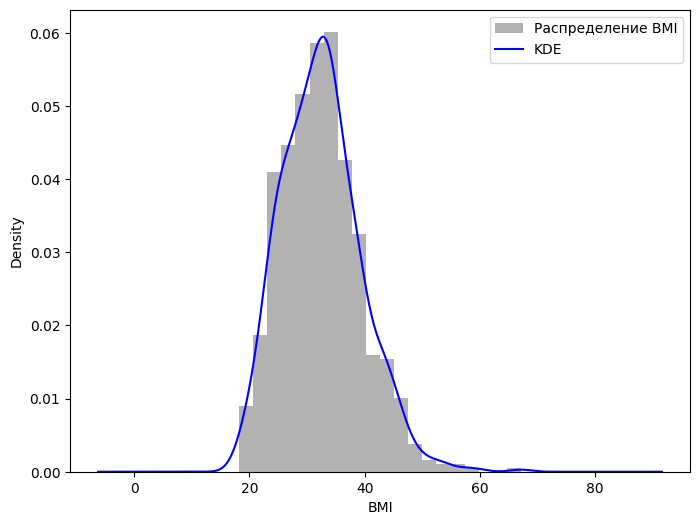

In [40]:
import numpy as np
from scipy.stats import norm

plt.figure(figsize=(8,6))
plt.hist(data['BMI'], bins=20, density=True, alpha=0.6, color='gray', label='Распределение BMI')
data['BMI'].plot(kind='kde', color='blue', label='KDE')
plt.xlabel('BMI')
plt.legend()
plt.show()


Постройте нормальное распределение поверх графика.

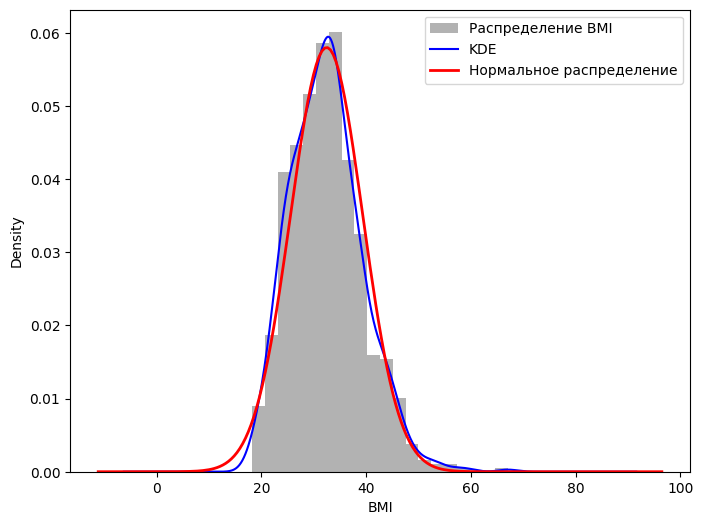

In [44]:
plt.figure(figsize=(8,6))
plt.hist(data['BMI'], bins=20, density=True, alpha=0.6, color='gray', label='Распределение BMI')
data['BMI'].plot(kind='kde', color='blue', label='KDE')

mu, std = data['BMI'].mean(), data['BMI'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Нормальное распределение')

plt.xlabel('BMI')
plt.legend()
plt.show()

Распределение BMI очень похоже на нормальное. В работе можем использовать для него принципы свойственные нормальному

## Задание 13

Постройте следующий график: процент больных диабетом в зависимости от числа беременностей.

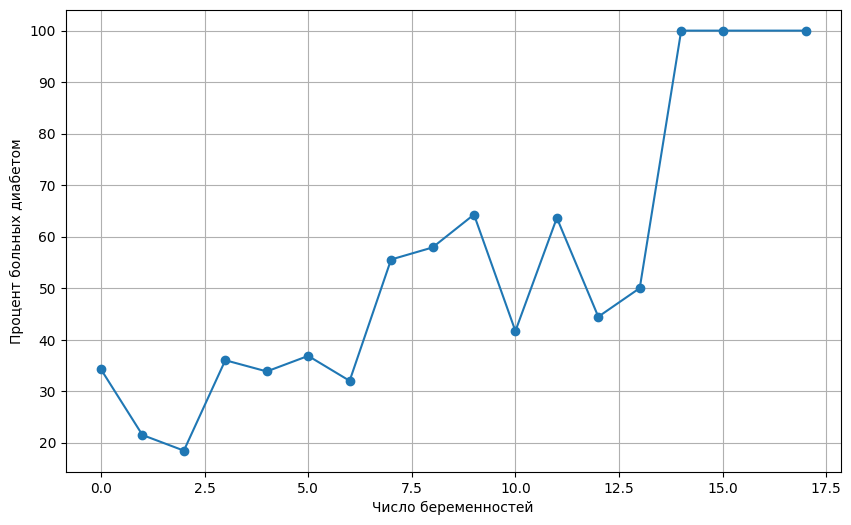

In [76]:
diabetes = data.groupby('Pregnancies')['Class'].mean() * 100
plt.figure(figsize=(10,6))
plt.plot(diabetes.index, diabetes.values, marker='o')
plt.xlabel('Число беременностей')
plt.ylabel('Процент больных диабетом')
plt.grid(True)
plt.show()

## Задание 14

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [71]:
data['wasPregnant'] = (data['Pregnancies'] > 0).astype(int)
print(data[['Pregnancies', 'wasPregnant']].head())


   Pregnancies  wasPregnant
0            6            1
1            1            1
2            8            1
3            1            1
4            0            0


## Задание 15

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [75]:
percent_preg = data[data['wasPregnant'] == 1]['Class'].mean() * 100
percent_not_preg = data[data['wasPregnant'] == 0]['Class'].mean() * 100

print(f'{percent_preg:.2f}%')
print(f'{percent_not_preg:.2f}%')


35.01%
34.23%


## Задание 16

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__
    
Underweight = <18.5

Normal weight = 18.5–24.9

Overweight = 25–29.9

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [73]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal weight'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obesity'

data['bodyType'] = data['BMI'].apply(bmi_category)
print(data[['BMI', 'bodyType']].head())


    BMI       bodyType
0  33.6        Obesity
1  26.6     Overweight
2  23.3  Normal weight
3  28.1     Overweight
4  43.1        Obesity


## Задание 17

Будем считать "здоровыми" тех, у кого нормальный вес и кровяное давление. Какой процент "здоровых" женщин больны диабетом?

In [78]:
healthy = data[(data['bodyType'] == 'Normal weight') & (data['BloodPressure'] >= 80) & (data['BloodPressure'] <= 89)]

percent = healthy['Class'].mean() * 100
print(f'{percent:.2f}%')

10.00%


# Часть II

Каждое задание в этой части оценивается в 1,15 баллов. Всего за выполнение этой части можно получить 3,45 балла.

In [50]:
babies = pd.read_csv(BABIES, index_col=0)
babies.head(10)

,name,sex,number,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
5,Margaret,F,1578,1880
6,Ida,F,1472,1880
7,Alice,F,1414,1880
8,Bertha,F,1320,1880
9,Sarah,F,1288,1880


## Задание 1

Исследуйте набор данных `babies`. Ответьте на вопросы.

1. Какие годы включает датасет

2. Какое имя в датасете находится по индексом 121?

3. Cколько всего родилось детей по имени 'Aaron' за все время?

4. Насколько больше за все время родилось мальчиков чем девочек?

5. Cколько мальчиков родилось в 2010?

6. Сколько в датасете девочек по имени John?

In [85]:
years = sorted(babies['year'].unique())
print("Годы в датасете:", *years)

Годы в датасете: 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010


In [93]:
names_121 = babies.loc[121, 'name']
print("Имена по индексу 121:", names_121)

Имена по индексу 121: 121       Ann
121      Anne
121     Josie
121      Lola
121     Hazel
        ...  
121       Eva
121     Naomi
121     Bella
121     Jenna
121    Nicole
Name: name, Length: 131, dtype: object


In [94]:
aaron_total = babies[babies['name'] == 'Aaron']['number'].sum()
print("Всего детей с именем 'Aaron':", aaron_total)

Всего детей с именем 'Aaron': 527668


In [95]:
boys = babies[babies['sex'] == 'M']['number'].sum()
girls = babies[babies['sex'] == 'F']['number'].sum()
difference = boys - girls
print("На", difference, "больше мальчиков, чем девочек.")

На 2422447 больше мальчиков, чем девочек.


In [96]:
boys_2010 = babies[(babies['year'] == 2010) & (babies['sex'] == 'M')]['number'].sum()
print("Мальчиков в 2010:", boys_2010)

Мальчиков в 2010: 1898382


In [97]:
girls_john = babies[(babies['name'] == 'John') & (babies['sex'] == 'F')]['number'].sum()
print("Девочек по имени John:", girls_john)

Девочек по имени John: 21578


## Задание 2

1. Сгруппируйте набор данных babies по году и полу и сохраните результаты в два новых датафрейма: baby_girls и baby_boys.

2. Создайте фигуру matplotlib с 3 графиками один под другим.

3. Постройте линейные графики. Первый график должен показывать тренд рождаемости для девочек, второй - для мальчиков, третий объединять их все вместе (с теми же цветами, что в индивидуальных графиках). Годы - x, количество детей - y.

4. Верхняя и правая границы графиков должны быть невидимы, к каждому графику должен быть заголовок, третий график должен содержать легенду, шкалы графиков должны быть подписаны.

5. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

6. Кратко опишите тренды в ячейке markdown под графиками.

Если при группировке вы сделали год индексом, то можно обратиться к значениям этой переменной через аттрибут `.index`

In [98]:
baby_girls = babies[babies['sex'] == 'F'].groupby('year')['number'].sum()
baby_boys = babies[babies['sex'] == 'M'].groupby('year')['number'].sum()


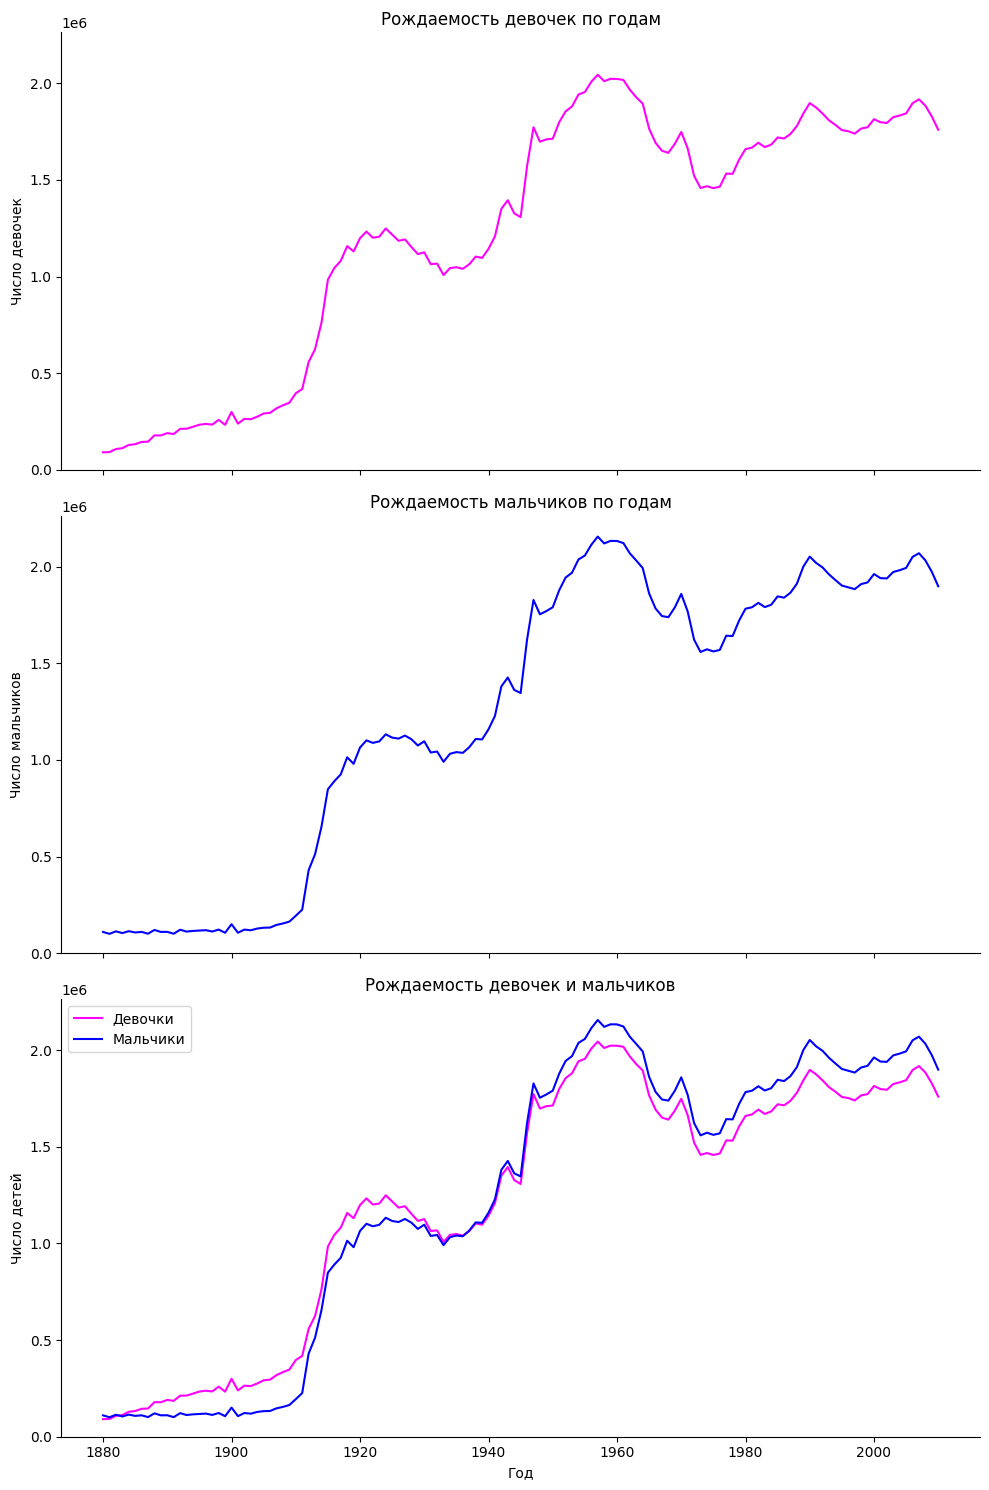

In [104]:
import matplotlib.pyplot as plt

years = baby_girls.index

fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

ymax = max(baby_girls.max(), baby_boys.max()) * 1.05

axs[0].plot(baby_girls.index, baby_girls.values, color='magenta')
axs[0].set_ylim(0, ymax)
axs[0].set_title('Рождаемость девочек по годам')
axs[0].set_ylabel('Число девочек')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[1].plot(baby_boys.index, baby_boys.values, color='blue')
axs[1].set_ylim(0, ymax)
axs[1].set_title('Рождаемость мальчиков по годам')
axs[1].set_ylabel('Число мальчиков')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[2].plot(baby_girls.index, baby_girls.values, color='magenta', label='Девочки')
axs[2].plot(baby_boys.index, baby_boys.values, color='blue', label='Мальчики')
axs[2].set_ylim(0, ymax)
axs[2].set_title('Рождаемость девочек и мальчиков')
axs[2].set_ylabel('Число детей')
axs[2].set_xlabel('Год')
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].legend()

plt.tight_layout()
plt.show()


#### Вывод
- где-то с 1940-х рождаемость мальчиков всегда чуть превышала рождаемость девочек.
- В начале XX века наблюдается резкий рост, потом застой к 1940-м опять рпезкий рост

## Задание 3

1. Сгруппируйте нужным способом датафрейм babies и найдите 4 самых популярных имени за всю историю (2 женских и 2 мужских).

2. Для каждого найденного имени создайте новый датафрейм вида babies_alisa и сохраните в него данные, сколько детей с таким именем рождалось каждый год.

3. Создайте фигуру matplotlib с 4 горизонтальными графиками один под другим.

4. Постройте 4 линейных графика - тренд для каждого имени за все время.

5. Каждый график должен содержать легенду, один общий заголовок, шкалы графиков должны быть подписаны.

6. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

7. Опишите тренды в ячейке markdown под графиками.

In [108]:
top_names = babies.groupby(['sex', 'name'])['number'].sum().reset_index()

top_girls = top_names[top_names['sex'] == 'F'].sort_values('number', ascending=False).head(2)
top_boys = top_names[top_names['sex'] == 'M'].sort_values('number', ascending=False).head(2)

print("Самые популярные девочки:", *list(top_girls['name']))
print("Самые популярные мальчики:", *list(top_boys['name']))

Самые популярные девочки: Mary Patricia
Самые популярные мальчики: James John


In [110]:
girl_name1 = top_girls['name'].iloc[0]
girl_name2 = top_girls['name'].iloc[1]
boy_name1 = top_boys['name'].iloc[0]
boy_name2 = top_boys['name'].iloc[1]

babies_girl1 = babies[babies['name'] == girl_name1].groupby('year')['number'].sum()
babies_girl2 = babies[babies['name'] == girl_name2].groupby('year')['number'].sum()
babies_boy1 = babies[babies['name'] == boy_name1].groupby('year')['number'].sum()
babies_boy2 = babies[babies['name'] == boy_name2].groupby('year')['number'].sum()


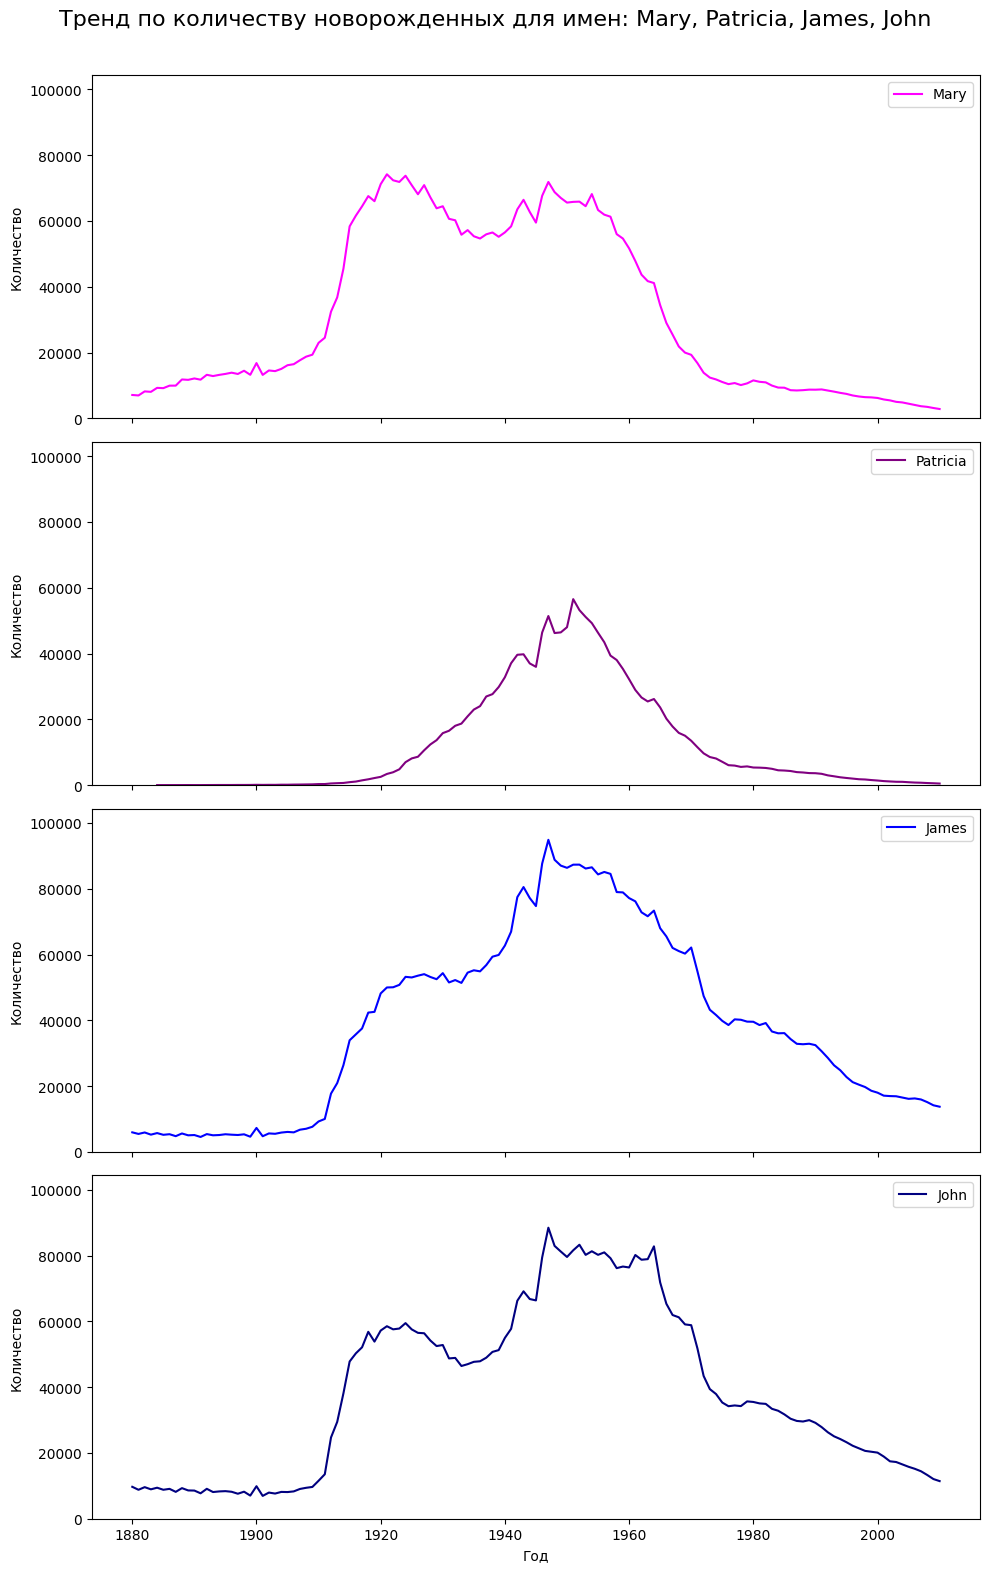

In [111]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

ymax = max(
    babies_girl1.max(),
    babies_girl2.max(),
    babies_boy1.max(),
    babies_boy2.max()
) * 1.1

axs[0].plot(babies_girl1.index, babies_girl1.values, color='magenta', label=girl_name1)
axs[0].set_ylabel('Количество')
axs[0].legend()
axs[0].set_ylim(0, ymax)

axs[1].plot(babies_girl2.index, babies_girl2.values, color='purple', label=girl_name2)
axs[1].set_ylabel('Количество')
axs[1].legend()
axs[1].set_ylim(0, ymax)

axs[2].plot(babies_boy1.index, babies_boy1.values, color='blue', label=boy_name1)
axs[2].set_ylabel('Количество')
axs[2].legend()
axs[2].set_ylim(0, ymax)

axs[3].plot(babies_boy2.index, babies_boy2.values, color='navy', label=boy_name2)
axs[3].set_ylabel('Количество')
axs[3].legend()
axs[3].set_ylim(0, ymax)
axs[3].set_xlabel('Год')

fig.suptitle(f'Тренд по количеству новорожденных для имен: {girl_name1}, {girl_name2}, {boy_name1}, {boy_name2}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#### Вывод

- Для всех четырёх имен наблюдается примерно одинаковый тренд: их максимальная популярность пришлась на середину XX века, после чего происходит резкий спад.

## Часть III

Каждое задание в этой части оценивается в 0,2 балла. Всего за выполнение этой части можно получить 4 балла.

Вам предлагается проанализировать датасет с Data - вакансиями.  
Скачайте его https://disk.yandex.ru/d/QUa3pCKVk48cAQ и считайте с помощью `pd.read_csv`.




In [114]:
df = pd.read_csv("/Users/firsov179/Downloads/vacancies.csv")

In [ ]:
df = pd.read_csv('Data_Vacancies.csv')


# Информация о столбцах и типах данных
df.info()

# Описательная статистика для числовых переменных
print(df.describe())

# Количество строк и столбцов
print("Строк:", df.shape[0], "Столбцов:", df.shape[1])


1. Выведите первые 5 и последние 5 строк датасета. Примените к датасету методы `info` и `describe`. Сколько в датасете строк и столбцов?

In [119]:
df.head(5)


,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


In [120]:
df.tail(5)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."
1526,1526,Senior Python Developer (Data Platform),Mindbox,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p><strong>Mindbox</strong> — крупнейшая в Рос...,"['Python', 'PySpark', 'Airflow', 'Kafka', 'Del..."


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          1527 non-null   int64 
 1   position_name       1527 non-null   object
 2   employer_name       1527 non-null   object
 3   area                1527 non-null   object
 4   experience          1527 non-null   object
 5   schedule            1527 non-null   object
 6   employment          1527 non-null   object
 7   professional_roles  1527 non-null   object
 8   salary              220 non-null    object
 9   description         1527 non-null   object
 10  key_skills          1527 non-null   object
dtypes: int64(1), object(10)
memory usage: 131.4+ KB


In [122]:
df.describe()

,Unnamed: 0
count,1527.000000
mean,763.000000
std,440.951244
min,0.000000
25%,381.500000
50%,763.000000
75%,1144.500000
max,1526.000000


In [123]:
print("Строк:", df.shape[0], "Столбцов:", df.shape[1])


Строк: 1527 Столбцов: 11


2. Есть ли в датасете пропуски?

In [128]:
print(df.isnull().any().any())

True


3. Есть в датасете полные дубли? Если да, удалите их (метод drop_duplicates).

In [130]:
duplicates = df.duplicated().sum()
print(f"Полных дублей: {duplicates}")

df = df.drop_duplicates()

Полных дублей: 0


4. Сколько уникальных значений у переменной professional_roles?

In [131]:
print(df['professional_roles'].nunique())

36


5. Сколько в датасете вакансий, не требующих опыта?

In [133]:
int((df['experience'] == 'Нет опыта').sum())

136

6. Какое среднее количество навыков в вакансии? (переменная key_skills)

In [135]:
def skills_count(x):
    if pd.isnull(x):
        return 0
    return len([s for s in x.split('\n') if s.strip() != ''])

df['skills_num'] = df['key_skills'].apply(skills_count)
print(float(df['skills_num'].mean()))


1.0


7. Какие валюты (ключ currency в поле salary) используются для заработной платы? Создайте столбец currency.  
*Подсказка. Как вариант, можете воспользоваться функцией eval, которая исполняет код, написанный в строке. Для проверки на NaN можете использовать pd.isnull()*

In [137]:
def get_currency(row):
    try:
        val = eval(str(row))
        if isinstance(val, dict) and 'currency' in val:
            return val['currency']
    except:
        return np.nan

df['currency'] = df['salary'].apply(get_currency)
print(df['currency'].unique())


['RUR' 'KZT' nan 'UZS' 'USD' 'EUR' 'BYR']


8. Какая компания лидирует по количеству вакансий?

In [138]:
print(df['employer_name'].value_counts().idxmax())

СБЕР


9.  Какая компания лидирует по количеству вакансий с указанием заработной платы?

In [139]:
print(df[~df['salary'].isnull()]['employer_name'].value_counts().idxmax())

Aston


10. Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в это столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to, используйте его) **(2)**

In [141]:
def extract_salary(sal):
    if pd.isnull(sal):
        return np.nan
    try:
        sal_dict = eval(str(sal))
        fr = sal_dict.get('from')
        to = sal_dict.get('to')
        if fr is not None and to is not None:
            return (fr + to) / 2
        elif fr is not None:
            return fr
        elif to is not None:
            return to
        else:
            return np.nan
    except:
        return np.nan

df['salary_num'] = df['salary'].apply(extract_salary)

11. Какая средняя заработная плата среди вакансий в рублях? А медианная заработная плата?  

In [144]:
df_rub = df[df['currency'] == 'RUR']
print(f"Средняя зарплата: {df_rub['salary_num'].mean():.1f}, медианная зарплата: {df_rub['salary_num'].median():.1f}")

Средняя зарплата: 195702.2, медианная зарплата: 150000.0


12. Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python.).  Какой процент вакансий требует знания python?

In [149]:
df['is_python_requirement'] = df['key_skills'].str.lower().str.contains('python', na=False).astype(int)
percent_python = df['is_python_requirement'].mean() * 100
print(f'{percent_python:.2f}%')

41.45%


13. Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях


In [153]:
agg_df = df.groupby(['experience', 'schedule', 'employment', 'is_python_requirement']).agg(
    vacancies_count = ('employer_name', 'size'),
    companies_count = ('employer_name', 'nunique'),
    mean_salary_rur = ('salary_num',
        lambda x: x[df.loc[x.index, 'currency'] == 'RUR'].mean())
).reset_index()
agg_df.head(10)

,experience,schedule,employment,is_python_requirement,vacancies_count,companies_count,mean_salary_rur
0,Более 6 лет,Гибкий график,Полная занятость,0,4,2,NaN
1,Более 6 лет,Гибкий график,Частичная занятость,0,1,1,NaN
2,Более 6 лет,Полный день,Полная занятость,0,49,30,220000.0
3,Более 6 лет,Полный день,Полная занятость,1,10,9,NaN
4,Более 6 лет,Удаленная работа,Полная занятость,0,11,7,NaN
5,Более 6 лет,Удаленная работа,Полная занятость,1,12,10,NaN
6,Нет опыта,Гибкий график,Полная занятость,1,2,2,225000.0
7,Нет опыта,Гибкий график,Стажировка,1,3,1,NaN
8,Нет опыта,Полный день,Полная занятость,0,26,17,105000.0
9,Нет опыта,Полный день,Полная занятость,1,55,6,92000.0


14. Создайте столбец count_skills. В нём должна быть длина списка, который находит в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]' Подумайте, как превратить её в список и посчитать его длину.  

In [157]:
def count_skills(sk):
    if pd.isnull(sk) or sk == '[]' or not sk:
        return 0
    if '\n' in sk:
        return len([s for s in sk.split('\n') if s.strip() != ''])
    if sk.startswith('[') and sk.endswith(']'):
        elems = sk[1:-1].replace("'", "").replace('"', '').split(', ')
        return len([x for x in elems if x and x.lower() != ''])
    return 1

df['count_skills'] = df['key_skills'].apply(count_skills)
df

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,skills_num,currency,salary_num,is_python_requirement,len_descr,count_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],1,RUR,372500.0,0,1583,0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],1,KZT,NaN,0,1310,0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",1,NaN,NaN,1,3760,11
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],1,NaN,NaN,0,1188,0
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",1,KZT,NaN,0,3355,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch...",1,NaN,NaN,1,4404,19
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[],1,NaN,NaN,0,3113,0
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[],1,NaN,NaN,0,2605,0
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra...",1,NaN,NaN,1,3192,9


15. Создайте столбец len_descr, в котором должна быть длина описания (description) в символах без учета html тегов ("<...>"). Напишите для этого функцию get_len_descr.  Можете использовать регулярные выражения.
То есть, ваш код может выглядеть, например, так:

In [159]:
import re
def get_len_descr(descr):
    if pd.isnull(descr):
        return 0
    clean_descr = re.sub('<[^<]+?>', '', descr)
    return len(clean_descr)

df['len_descr'] = df['description'].apply(get_len_descr)
df

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills,skills_num,currency,salary_num,is_python_requirement,len_descr,count_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[],1,RUR,372500.0,0,1583,0
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[],1,KZT,NaN,0,1310,0
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe...",1,NaN,NaN,1,3760,11
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[],1,NaN,NaN,0,1188,0
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']",1,KZT,NaN,0,3355,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch...",1,NaN,NaN,1,4404,19
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[],1,NaN,NaN,0,3113,0
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[],1,NaN,NaN,0,2605,0
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra...",1,NaN,NaN,1,3192,9


16. Постройте таблицу корреляций с тремя переменными: salary_num, len_descr, count_skills.  

In [161]:
corr_table = df[['salary_num', 'len_descr', 'count_skills']].corr()
corr_table

,salary_num,len_descr,count_skills
salary_num,1.000000,-0.139022,-0.118577
len_descr,-0.139022,1.000000,0.126049
count_skills,-0.118577,0.126049,1.000000


17. Постройте тепловую карту из таблицы из предыдущего пункта.

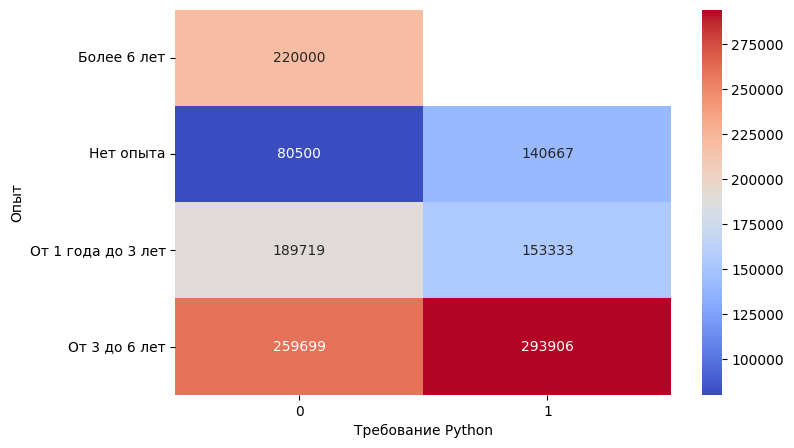

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = agg_df.pivot_table(
    index='experience',
    columns='is_python_requirement',
    values='mean_salary_rur'
)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.xlabel('Требование Python')
plt.ylabel('Опыт')
plt.show()


18. Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

In [164]:
from collections import Counter

all_skills = []
for skills in df['key_skills']:
    if pd.isnull(skills) or skills.strip() in ('', '[]'):
        continue
    if skills.startswith('[') and skills.endswith(']'):
        elems = [x.strip(" '\"") for x in skills.strip('[]').split(',')]
        all_skills.extend([s for s in elems if s])
    elif '\n' in skills:
        all_skills.extend([s.strip() for s in skills.split('\n') if s.strip()])
    else:
        all_skills.append(skills.strip())

counter = Counter(all_skills)
top10 = counter.most_common(10)
print("Топ-10 самых востребованных скиллов:")
for skill, count in top10:
    print(f'{skill}: {count}')


Топ-10 самых востребованных скиллов:
Python: 633
SQL: 574
ETL: 154
Big Data: 146
Hadoop: 118
PostgreSQL: 113
DWH: 111
Clickhouse: 102
Английский язык: 93
Математический анализ: 90


19. Постройте гистограмму распределения зарплаты среди вакансий в рублях.  

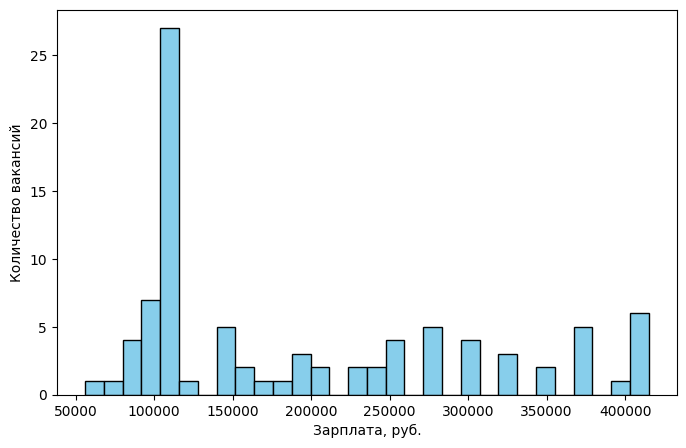

In [166]:
plt.figure(figsize=(8,5))
df[df['currency'] == 'RUR']['salary_num'].dropna().plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Зарплата, руб.')
plt.ylabel('Количество вакансий')
plt.show()

20. Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience

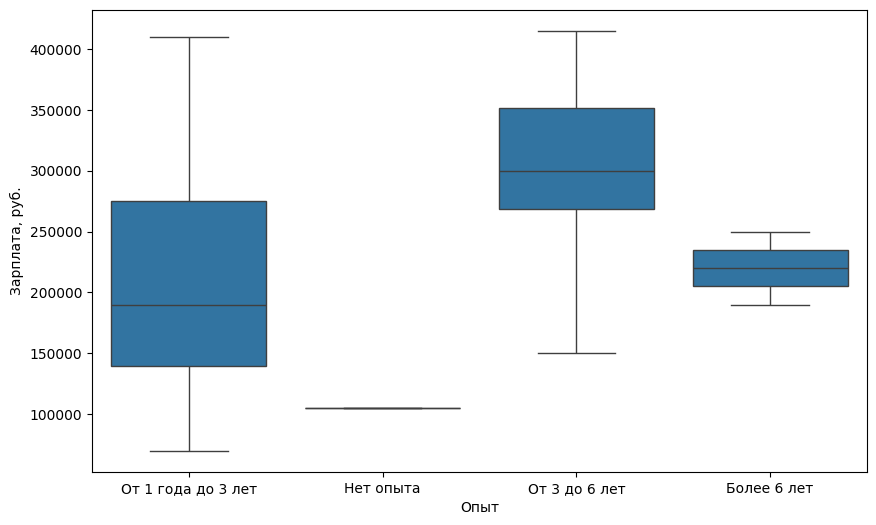

In [167]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='experience',
    y='salary_num',
    data=df[df['currency'] == 'RUR'],
    showfliers=False
)
plt.xlabel('Опыт')
plt.ylabel('Зарплата, руб.')
plt.show()
